# 💳 Detección de Fraude en Tarjetas de Crédito

**Objetivo del Proyecto:** Desarrollar un sistema de Machine Learning capaz de identificar transacciones fraudulentas en un volumen masivo de datos. 

**Enfoque Técnico:**
- Optimización de memoria y procesamiento eficiente con Pandas y NumPy.
- Ingeniería de características espaciales y temporales avanzadas.
- Tratamiento de clases altamente desbalanceadas.
- Modelado predictivo enfocado en la métrica PR-AUC.

---

## 1. Configuración Inicial e Importación de Librerías

In [2]:
import pandas as pd
import numpy as np

# Configuración del entorno de visualización del notebook
import warnings
warnings.filterwarnings("ignore") # Oculta avisos molestos de versiones

# Ajustes de Pandas para que no nos oculte columnas al visualizar el DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x) # Evita notación científica


## 2. Ingesta de Datos y Optimización de Memoria (Downcasting)

Al trabajar con más de un millón de transacciones, la eficiencia computacional es una prioridad. Por defecto, Pandas asigna 64 bits a todas las variables numéricas, lo cual genera un consumo de memoria RAM innecesario. 

Para evitarlo, aplicaremos una técnica de **downcasting** desde el propio momento de la lectura. Reduciremos los tipos de datos (por ejemplo, asignando 8 bits a la variable binaria objetivo `is_fraud`) y utilizaremos el motor de `pyarrow` (basado en C++) para la ingesta. Esto no solo comprime la huella de memoria, sino que permite que las futuras operaciones matemáticas se resuelvan de forma mucho más rápida al aprovechar mejor la memoria caché del procesador.

In [4]:
# Ruta absoluta al dataset (usamos 'r' para evitar problemas con las barras de Windows)
dataset_path = r"C:\Users\marti\Portfolio-data-science\ML_Credit_Card_Fraud_Detection\data\credit_card_transactions.csv"

# Definición estricta de tipos de datos para el downcasting
dtypes = {
    'cc_num': 'int64',        # Identificador de la tarjeta (requiere 64 bits por su longitud)
    'amt': 'float32',         # Importe de la transacción
    'lat': 'float32',         # Coordenadas espaciales
    'long': 'float32',
    'merch_lat': 'float32',
    'merch_long': 'float32',
    'city_pop': 'int32',      # Población urbana
    'is_fraud': 'int8'        # Variable objetivo binaria (0 o 1)
}

# Carga apalancada en pyarrow con parseo de fechas al vuelo
print("Cargando el dataset en memoria...")
df = pd.read_csv(
    dataset_path, 
    dtype=dtypes,
    engine='pyarrow',
    parse_dates=['trans_date_trans_time', 'dob']
)

# Limpieza del índice residual de la exportación original
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Comprobación de dimensiones y memoria liberada
print(f"Dimensiones del dataset: {df.shape}\n")
df.info(memory_usage='deep')

Cargando el dataset en memoria...
Dimensiones del dataset: (1296675, 23)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[s] 
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float32       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip            

## 3. Feature Engineering: Variables Espaciales, Temporales y Demográficas

Los algoritmos de Machine Learning no interpretan fechas ni coordenadas brutas de forma eficiente. Para maximizar el poder predictivo, debemos extraer la "señal" subyacente mediante la creación de nuevas variables (*features*):

1. **Señal Espacial:** Calcularemos la distancia ortodrómica (Haversine) entre la ubicación del cliente y el comercio. Transacciones presenciales a gran distancia en cortos periodos de tiempo son fuertes predictores de fraude.
2. **Señal Demográfica:** Convertiremos la fecha de nacimiento (`dob`) en la edad del usuario en el momento de la transacción.
3. **Señal Temporal:** Extraeremos la hora del día y el día de la semana. El fraude suele presentar asimetrías horarias (ej. picos de madrugada).

In [ ]:
# Función vectorizada para el cálculo de distancia Haversine en C, se usa esta forma de calculo ya que la Tierra se presume que es una esfera perfecta y no un elipsoide, lo que simplifica los cálculos de distancia entre dos puntos geográficos.
# se calcula de manera vectorizada para evitar un bucle for con .apply() que es mucho más lento y costoso computacionalmente.
def haversine_vectorized(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

df['distancia_km'] = haversine_vectorized(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Edad del cliente en el momento exacto de la compra
df['edad'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Hora (0-23) y Día de la semana (0=Lunes, 6=Domingo)
df['hora_transaccion'] = df['trans_date_trans_time'].dt.hour
df['dia_semana'] = df['trans_date_trans_time'].dt.dayofweek

# Visualizamos una muestra de las nuevas variables predictoras junto a la variable objetivo
columnas_nuevas = ['trans_date_trans_time', 'distancia_km', 'edad', 'hora_transaccion', 'dia_semana', 'amt', 'is_fraud']
display(df[columnas_nuevas].head())

,trans_date_trans_time,distancia_km,edad,hora_transaccion,dia_semana,amt,is_fraud
0,2019-01-01 00:00:18,78.5975,30,0,1,4.9700,0
1,2019-01-01 00:00:44,30.2122,40,0,1,107.2300,0
2,2019-01-01 00:00:51,108.2061,56,0,1,220.1100,0
3,2019-01-01 00:01:16,95.6738,52,0,1,45.0000,0
4,2019-01-01 00:03:06,77.5564,32,0,1,41.9600,0


## 4. Análisis Exploratorio (EDA): Desbalanceo y Patrones Temporales

El objetivo de esta sección es auditar la distribución de la variable objetivo (`is_fraud`) y analizar la separación de varianza en nuestras nuevas *features* temporales. 

Dado que el fraude es un evento anómalo, visualizaremos la **densidad de probabilidad** de las transacciones legítimas frente a las fraudulentas a lo largo del día. Usar densidades en lugar de recuentos absolutos (KDE - *Kernel Density Estimation*) nos permite comparar la "forma" del comportamiento horario ignorando la masiva diferencia en volumen entre ambas clases.

--- Auditoría de Desbalanceo de Clases ---


,Volumen Absoluto,Proporción (%)
Legítimas (0),1289169,99.4211
Fraude (1),7506,0.5789


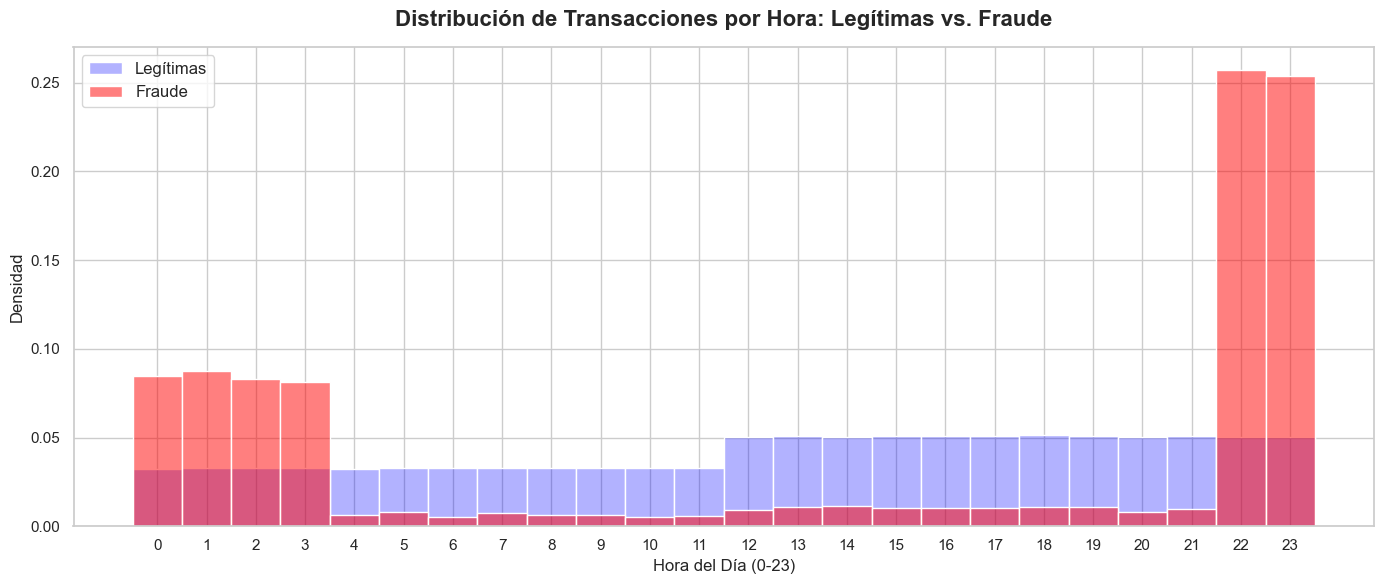

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para los gráficos
sns.set_theme(style="whitegrid", palette="muted")

print("--- Auditoría de Desbalanceo de Clases ---")
# Calculamos frecuencias absolutas y relativas
frecuencias = df['is_fraud'].value_counts()
porcentajes = df['is_fraud'].value_counts(normalize=True) * 100

resumen_fraude = pd.DataFrame({
    'Volumen Absoluto': frecuencias,
    'Proporción (%)': porcentajes
})
resumen_fraude.index = ['Legítimas (0)', 'Fraude (1)']
display(resumen_fraude)


# Gráfico de distribución discreta normalizada
plt.figure(figsize=(14, 6))

# Usamos histplot con discrete=True para que se ciña a las horas enteras (0, 1, 2...)
sns.histplot(data=df[df['is_fraud'] == 0], x='hora_transaccion', color='blue', label='Legítimas', stat='density', discrete=True, alpha=0.3)
sns.histplot(data=df[df['is_fraud'] == 1], x='hora_transaccion', color='red', label='Fraude', stat='density', discrete=True, alpha=0.5)

# Formateo del gráfico
plt.title('Distribución de Transacciones por Hora: Legítimas vs. Fraude', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Proyección cíclica de las variables temporales (hora del día y día de la semana) usando funciones trigonométricas para capturar la naturaleza circular de estas características. Esto es crucial para modelos que no manejan bien la discontinuidad entre el final y el inicio del ciclo (por ejemplo, entre las 23:00 y las 00:00 horas).

In [10]:
# Transformación trigonométrica para la hora del día (ciclo de 24 horas)
df['hora_sin'] = np.sin(2 * np.pi * df['hora_transaccion'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_transaccion'] / 24)

# Transformación trigonométrica para el día de la semana (ciclo de 7 días)
df['dia_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
df['dia_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)

# Visualizamos la transformación
display(df[['hora_transaccion', 'hora_sin', 'hora_cos']].head())

,hora_transaccion,hora_sin,hora_cos
0,0,0.0000,1.0000
1,0,0.0000,1.0000
2,0,0.0000,1.0000
3,0,0.0000,1.0000
4,0,0.0000,1.0000
